# DTDC Delivery Intelligence Platform
## End-to-End Data Science Project: Temporal Forecasting, Delay Analysis, Pricing Optimization and Geo-Demand Heatmapping
##### **Project prepared by** Sandipan Acharjee
---

### Project Context and Business Problem
DTDC is one of India's largest courier networks. With nearly 50,000 shipment records across 36 cities and 22 states, the business is sitting on a goldmine of operational intelligence it has not yet extracted.
The questions management is asking are:

Which cities and corridors are sending and receiving the most parcels, and where is demand growing over time?
Where are parcels getting delayed, and can we predict those delays before they happen?
Are we pricing our routes correctly, or are we undercharging on high-demand corridors and overcharging on low-demand ones?
Which future city-pairs are likely to become revenue hotspots but are currently constrained by logistics capacity?

We will answer all four questions in sequence, ending with a deployable API inside Docker so the models can be used in production.

### Part 1: Environment Setup

In [2]:
# install all required libraries in one go
# prophet is Meta's open-source time series forecasting library
# h3 is Uber's geo-indexing library for hexagonal map grids
# folium creates interactive maps in Python
# statsmodels gives us SARIMA for classical time series

import subprocess
subprocess.run([
    "pip", "install", "prophet", "h3", "folium", "statsmodels",
    "scikit-learn", "xgboost", "shap", "matplotlib", "seaborn",
    "pandas", "numpy", "--quiet"
])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime, timedelta

# set a consistent visual style for all plots
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
sns.set_palette("muted")

print("Libraries loaded successfully.")

Libraries loaded successfully.


### Part 2: Loading and First Look at the Data

In [3]:
#load the full dataset
df = pd.read_csv("Dataset_Generator_for_DTDC.csv")

print(f"Total records  : {df.shape[0]:,}")
print(f"Total columns  : {df.shape[1]}")
print(f"\nData types:\n{df.dtypes}")

Total records  : 49,639
Total columns  : 42

Data types:
Origin                       str
Destination                  str
Pouch No                     str
Date                         str
Sender's Name                str
Sender Phone               int64
Sender Address               str
Sender City                  str
Sender State                 str
Sender Pincode             int64
Sender GSTIN                 str
Total Pieces               int64
Actual Wt                float64
Volumetric Wt            float64
Chargeable Wt            float64
Paperwork                    str
Sender Signature             str
Sender Date                  str
Recipient Name               str
Recipient Phone            int64
Recipient Address            str
Recipient City               str
Receiver State               str
Receiver Pincode           int64
Description                  str
Value Added Services         str
Consignment No               str
Expiry Date                  str
Booking Code       

In [4]:
df.head()

,Origin,Destination,Pouch No,Date,Sender's Name,Sender Phone,Sender Address,Sender City,Sender State,Sender Pincode,...,Company Stamp,Receiver Signature,Receive Date,Tariff,VAS Charges,Total Amount,Mode,Risk Surcharge,Mode of Payment,Nature of Consignment
0,Nagpur,Jamshedpur,55e275ad-8da9-49c9-986c-93134fef2c19,2025-06-25,Megha Majumdar,6137840452,"H.No. 425 Varughese Chowk, Above Shop, Nagpur,...",Nagpur,Maharashtra,264582,...,NaN,NaN,2025-06-30,147.22,70.09,217.31,Express,Carrier,Cash,Dox
1,Jaipur,Vizag,7fab4175-11b2-4090-a0ed-4571ccd68878,2025-06-27,Nanda-Saraf,52907142,"48/880, Tripathi, Above Shop, Jaipur, Rajastha...",Jaipur,Rajasthan,200155,...,NaN,NaN,2025-06-28,256.83,82.20,339.03,Surface,Carrier,Card,Dox
2,Lucknow,Bhubaneswar,5231428d-b524-433e-8043-45c7e39a94aa,2025-06-27,Contractor LLC,5081512738,"257, Kulkarni Path, Above Shop, Lucknow, Uttar...",Lucknow,Uttar Pradesh,353311,...,NaN,NaN,2025-06-28,432.45,107.63,540.08,Surface,Carrier,Cash,Non-Dox
3,Coimbatore,Mumbai,2f556b38-298d-4e8c-9310-4e6a3a5fbe61,2025-06-11,Krishna Hans,1518559754,"83/17 Sridhar Zila, Above Shop, Coimbatore, Ta...",Coimbatore,Tamil Nadu,553663,...,NaN,NaN,2025-06-15,1162.00,25.23,1187.23,Express,Carrier,Card,Non-Dox
4,Meerut,Vijayawada,c3154041-34eb-435e-94d8-0900e6a9ed01,2025-07-01,Kuruvilla-Tiwari,1666398391,"16/64 Jayaraman Circle, Above Shop, Meerut, Ut...",Meerut,Uttar Pradesh,273143,...,NaN,NaN,2025-07-05,285.55,67.70,353.25,Surface,Carrier,Cash,Dox


Now let us look at what each column is telling us. There are 42 columns covering the sender side (city, state, pincode, GSTIN, weight), the consignment logistics (mode, tariff, VAS charges, total amount), and the receiver side (city, state, receive date). That gives us everything we need.

In [5]:
# missing values are important to flag early
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
print(missing_report[missing_report.missing_count > 0].sort_values("missing_pct", ascending=False))

                      missing_count  missing_pct
Recipient GSTIN               35773        72.07
Company Stamp                 29774        59.98
Receiver Signature            29774        59.98
Sender GSTIN                  22861        46.05
Sender Signature              19828        39.94
Value Added Services          10240        20.63


The columns with high missingness are Recipient GSTIN (72%), Company Stamp (60%), Receiver Signature (60%), Sender Signature (40%), and Sender GSTIN (46%). These are either optional fields or fields specific to B2B shipments. We will drop them from our modelling but keep them as a flag indicating whether a shipment is B2B or B2C.

### Part 3: Data Cleaning

In [6]:
# parse dates properly so Python knows these are dates not strings
df["Date"] = pd.to_datetime(df["Date"])
df["Receive Date"] = pd.to_datetime(df["Receive Date"])
df["Sender Date"] = pd.to_datetime(df["Sender Date"])
df["Expiry Date"] = pd.to_datetime(df["Expiry Date"])

print("Date range of bookings:", df["Date"].min(), "to", df["Date"].max())
print("Date range of deliveries:", df["Receive Date"].min(), "to", df["Receive Date"].max())

Date range of bookings: 2025-06-06 00:00:00 to 2025-07-05 00:00:00
Date range of deliveries: 2025-06-07 00:00:00 to 2025-07-10 00:00:00


In [7]:
# derived feature: how many days did delivery actually take?
# this is the most important operational metric in logistics
df["transit_days"] = (df["Receive Date"] - df["Date"]).dt.days

# sanity check: transit days should be positive
print("Negative transit days (data errors):", (df["transit_days"] < 0).sum())
print("Zero transit days (same day delivery - possible):", (df["transit_days"] == 0).sum())
print("\nTransit days distribution:")
print(df["transit_days"].describe())

Negative transit days (data errors): 0
Zero transit days (same day delivery - possible): 0

Transit days distribution:
count    49639.000000
mean         2.997965
std          1.409739
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: transit_days, dtype: float64


In [8]:
# create a B2B flag: if the sender has a GSTIN it is a business shipment
df["is_b2b"] = df["Sender GSTIN"].notna().astype(int)

# create a VAS flag: value added service was opted in or not
df["has_vas"] = df["Value Added Services"].notna().astype(int)

# drop high-missingness columns that carry no predictive value
cols_to_drop = ["Sender GSTIN", "Recipient GSTIN", "Company Stamp",
                "Receiver Signature", "Sender Signature", "Pouch No",
                "Consignment No", "Booking Code", "Expiry Date"]
df.drop(columns=cols_to_drop, inplace=True)

print("Remaining columns:", df.shape[1])

Remaining columns: 36


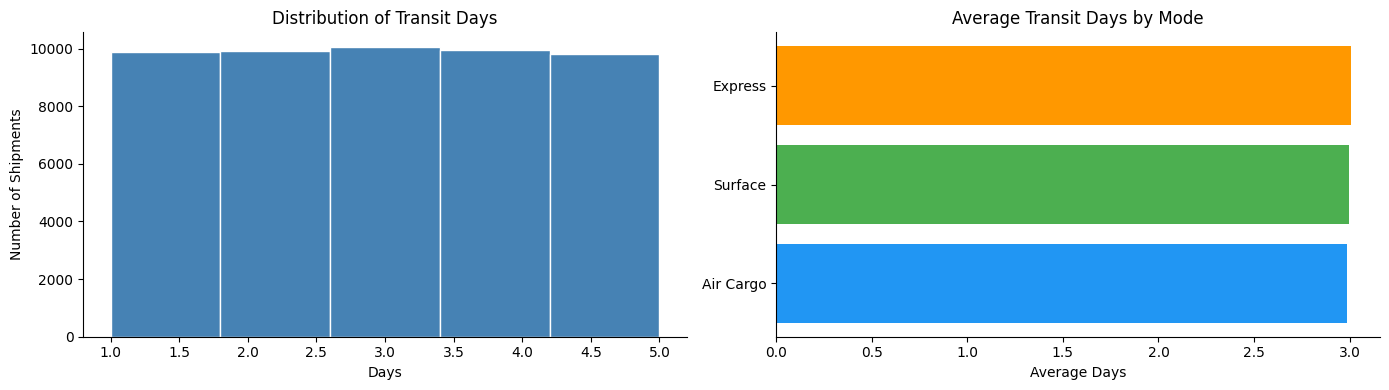

In [9]:
# quick visual check of transit days
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["transit_days"], bins=5, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Transit Days")
axes[0].set_xlabel("Days")
axes[0].set_ylabel("Number of Shipments")

# mode-wise transit time comparison
mode_transit = df.groupby("Mode")["transit_days"].mean().sort_values()
axes[1].barh(mode_transit.index, mode_transit.values, color=["#2196F3","#4CAF50","#FF9800"])
axes[1].set_title("Average Transit Days by Mode")
axes[1].set_xlabel("Average Days")

plt.tight_layout()
plt.savefig("transit_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

### Part 4: Exploratory Data Analysis
This section is about letting the data speak. We are not yet modelling anything. We are building a business understanding of flows, revenue, delays and patterns.

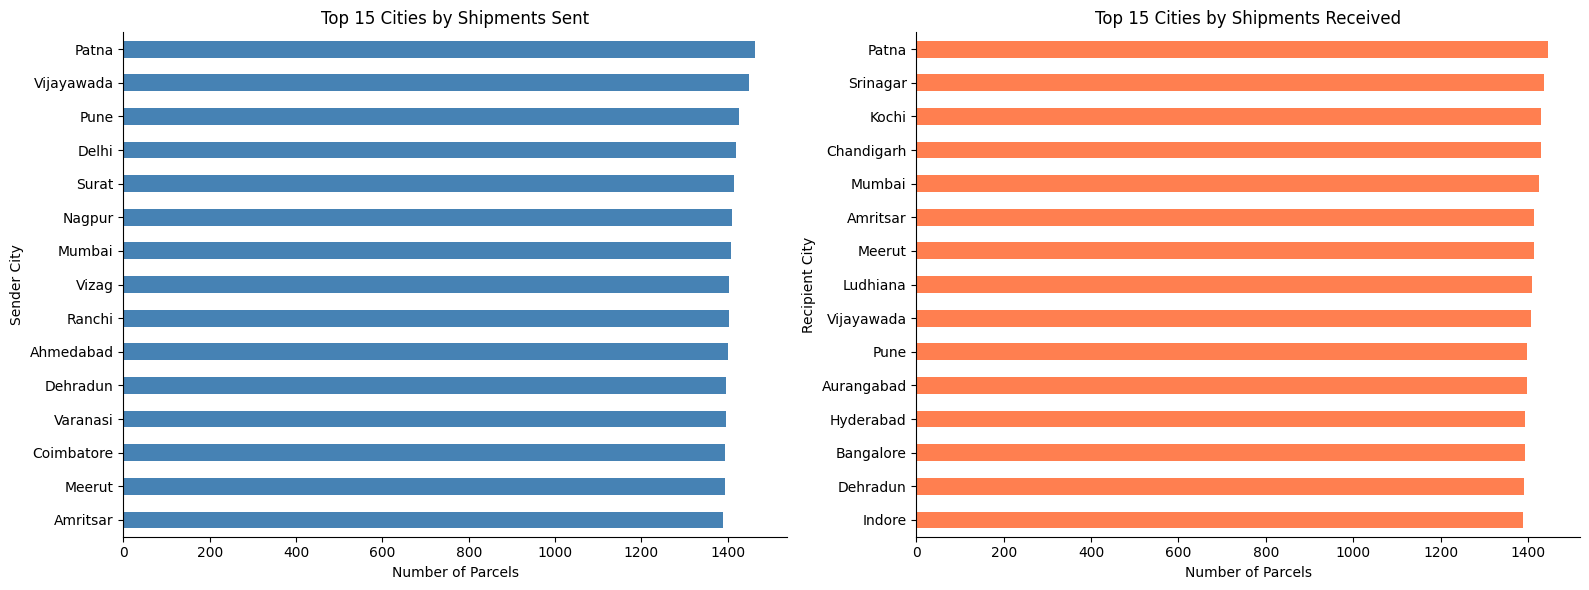

In [10]:
# top sender cities by total shipments
sender_vol = df["Sender City"].value_counts().head(15)
receiver_vol = df["Recipient City"].value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sender_vol.plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Top 15 Cities by Shipments Sent")
axes[0].set_xlabel("Number of Parcels")
axes[0].invert_yaxis()

receiver_vol.plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Top 15 Cities by Shipments Received")
axes[1].set_xlabel("Number of Parcels")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("top_cities.png", dpi=150, bbox_inches="tight")
plt.show()

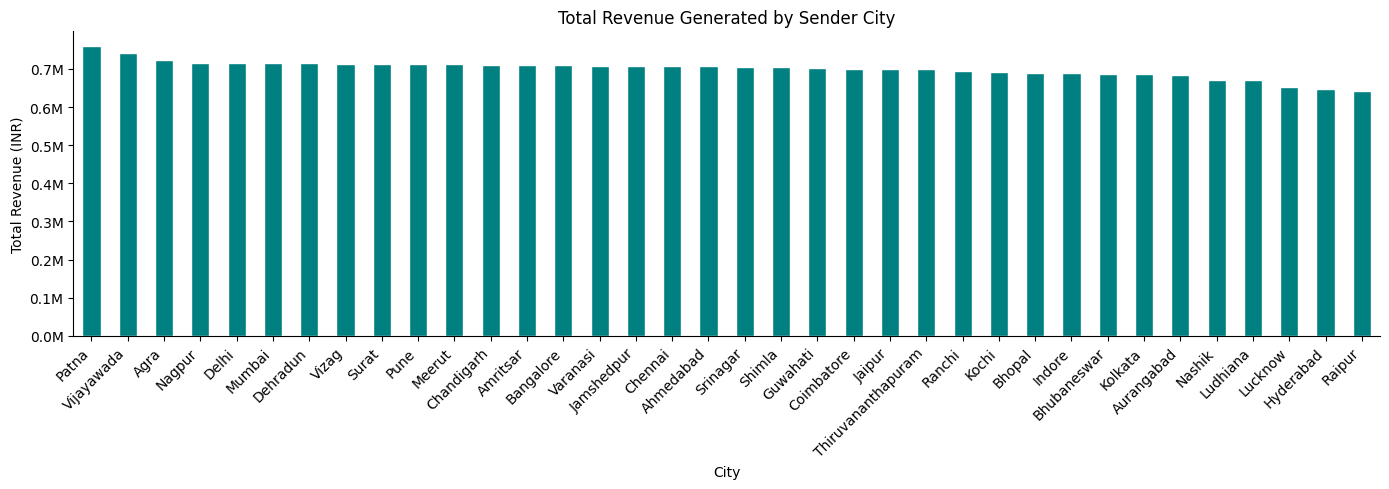

In [11]:
# revenue analysis by city
city_revenue = df.groupby("Sender City")["Total Amount"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
city_revenue.plot(kind="bar", ax=ax, color="teal", edgecolor="white")
ax.set_title("Total Revenue Generated by Sender City")
ax.set_xlabel("City")
ax.set_ylabel("Total Revenue (INR)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("city_revenue.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# delay analysis: a shipment is "delayed" if it took more than 3 days
# 3 days is a reasonable benchmark for surface mode in India
df["is_delayed"] = (df["transit_days"] > 3).astype(int)

delay_by_city_pair = df.groupby(["Sender City", "Recipient City"])["is_delayed"].mean().reset_index()
delay_by_city_pair.columns = ["Sender City", "Recipient City", "delay_rate"]
delay_by_city_pair = delay_by_city_pair.sort_values("delay_rate", ascending=False)

print("Top 15 corridors with highest delay rates:")
print(delay_by_city_pair.head(15).to_string(index=False))

Top 15 corridors with highest delay rates:
Sender City     Recipient City  delay_rate
    Chennai              Patna    0.647059
     Ranchi         Chandigarh    0.629630
     Nagpur              Kochi    0.625000
   Ludhiana Thiruvananthapuram    0.625000
     Meerut            Lucknow    0.617647
   Dehradun             Nagpur    0.605263
      Kochi              Patna    0.600000
     Ranchi            Chennai    0.600000
     Nashik            Lucknow    0.600000
   Dehradun         Aurangabad    0.600000
 Jamshedpur             Bhopal    0.600000
     Nashik            Kolkata    0.589744
     Nagpur          Hyderabad    0.586957
     Nashik           Ludhiana    0.585366
   Amritsar         Coimbatore    0.583333


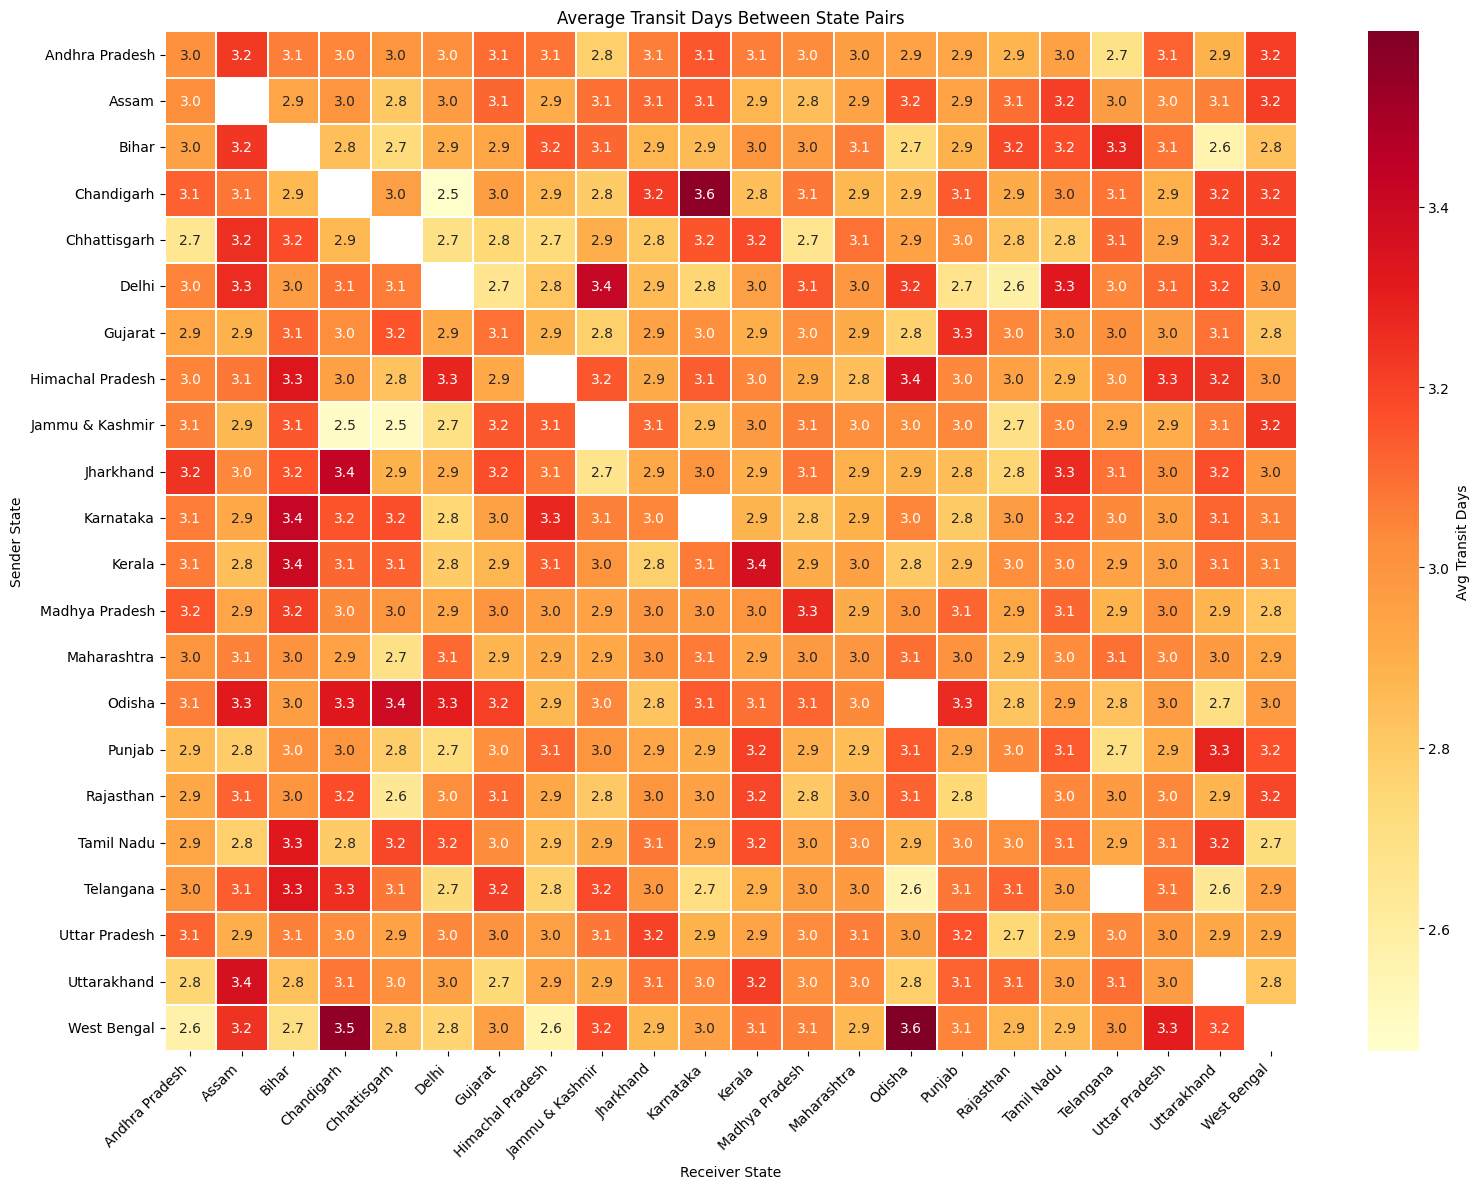

In [13]:
# heatmap of transit days between state pairs
state_transit = df.groupby(["Sender State", "Receiver State"])["transit_days"].mean().unstack()

fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(state_transit, cmap="YlOrRd", linewidths=0.3,
            annot=True, fmt=".1f", ax=ax, cbar_kws={"label": "Avg Transit Days"})
ax.set_title("Average Transit Days Between State Pairs")
ax.set_xlabel("Receiver State")
ax.set_ylabel("Sender State")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("state_transit_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

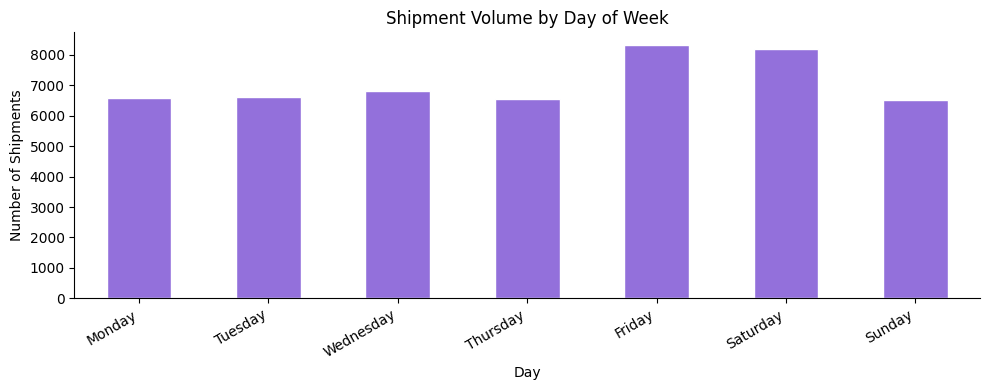

In [14]:
# weekly demand pattern: does demand spike on certain days?
df["day_of_week"] = df["Date"].dt.day_name()
df["week_number"] = df["Date"].dt.isocalendar().week.astype(int)
df["month"] = df["Date"].dt.month

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_demand = df.groupby("day_of_week").size().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 4))
day_demand.plot(kind="bar", ax=ax, color="mediumpurple", edgecolor="white")
ax.set_title("Shipment Volume by Day of Week")
ax.set_xlabel("Day")
ax.set_ylabel("Number of Shipments")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("weekday_demand.png", dpi=150, bbox_inches="tight")
plt.show()

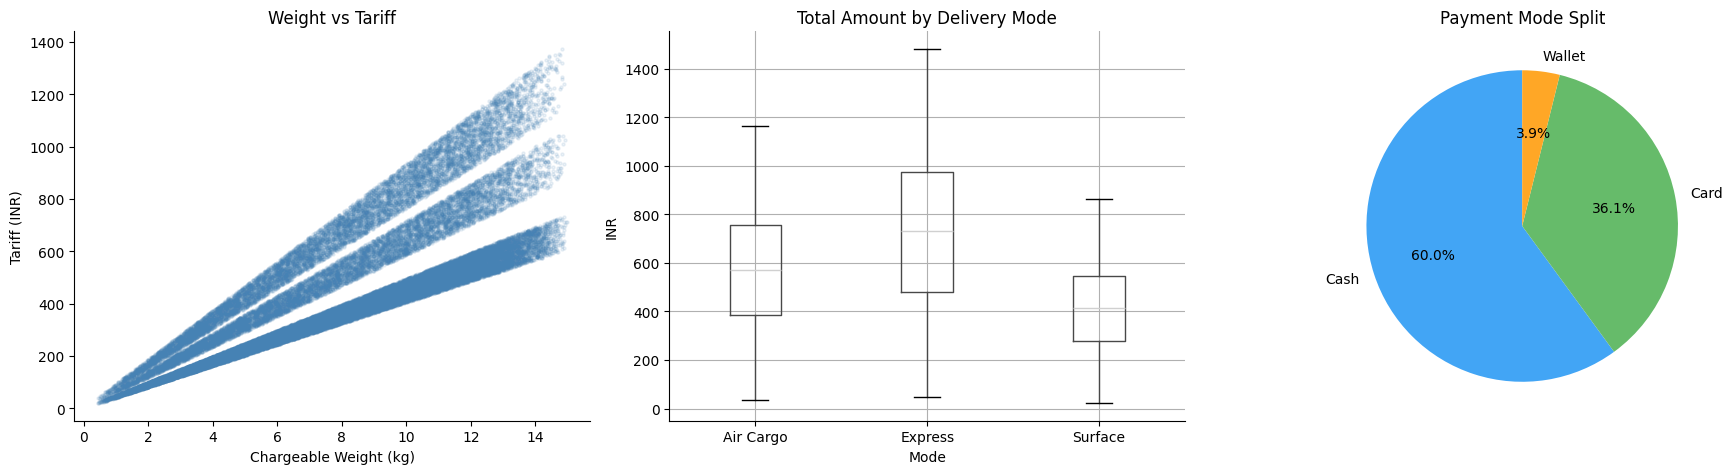

In [15]:
# pricing analysis: how does tariff vary with weight and mode?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# scatter: chargeable weight vs tariff
axes[0].scatter(df["Chargeable Wt"], df["Tariff"],
                alpha=0.1, s=5, c="steelblue")
axes[0].set_xlabel("Chargeable Weight (kg)")
axes[0].set_ylabel("Tariff (INR)")
axes[0].set_title("Weight vs Tariff")

# boxplot: mode vs total amount
df.boxplot(column="Total Amount", by="Mode", ax=axes[1])
axes[1].set_title("Total Amount by Delivery Mode")
axes[1].set_xlabel("Mode")
axes[1].set_ylabel("INR")

# payment mode distribution
df["Mode of Payment"].value_counts().plot(kind="pie", ax=axes[2],
    autopct="%1.1f%%", startangle=90,
    colors=["#42A5F5","#66BB6A","#FFA726"])
axes[2].set_title("Payment Mode Split")
axes[2].set_ylabel("")

plt.suptitle("")
plt.tight_layout()
plt.savefig("pricing_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

### Part 5: Feature Engineering
Feature engineering is the bridge between raw data and machine learning. We are creating new columns that capture business logic which raw columns cannot express alone.

In [16]:
# route feature: combining sender and receiver cities
df["route"] = df["Sender City"] + "_to_" + df["Recipient City"]

# weight ratio: how much does volumetric weight deviate from actual weight?
# if volumetric_wt >> actual_wt, the parcel is bulky but light (packaging heavy items)
# this ratio affects pricing strategy
df["vol_to_actual_ratio"] = df["Volumetric Wt"] / df["Actual Wt"].replace(0, np.nan)

# revenue per kg: how efficiently are we monetising each kilo of capacity?
df["revenue_per_kg"] = df["Total Amount"] / df["Chargeable Wt"].replace(0, np.nan)

# is this an inter-state shipment?
df["is_inter_state"] = (df["Sender State"] != df["Receiver State"]).astype(int)

# encode categorical variables for ML
from sklearn.preprocessing import LabelEncoder

le_mode = LabelEncoder()
le_nature = LabelEncoder()
le_payment = LabelEncoder()

df["mode_enc"] = le_mode.fit_transform(df["Mode"])
df["nature_enc"] = le_nature.fit_transform(df["Nature of Consignment"])
df["payment_enc"] = le_payment.fit_transform(df["Mode of Payment"])

print("Feature engineering complete.")
print(df[["route", "vol_to_actual_ratio", "revenue_per_kg",
          "is_inter_state", "transit_days", "is_delayed"]].describe())

Feature engineering complete.
       vol_to_actual_ratio  revenue_per_kg  is_inter_state  transit_days  \
count         49639.000000    49639.000000    49639.000000  49639.000000   
mean              1.489969       69.177998        0.962691      2.997965   
std               0.801566       22.246605        0.189521      1.409739   
min               1.008446       40.500673        0.000000      1.000000   
25%               1.133929       51.976271        1.000000      2.000000   
50%               1.252110       63.669118        1.000000      3.000000   
75%               1.472074       83.308631        1.000000      4.000000   
max              10.800000      373.977778        1.000000      5.000000   

         is_delayed  
count  49639.000000  
mean       0.398376  
std        0.489569  
min        0.000000  
25%        0.000000  
50%        0.000000  
75%        1.000000  
max        1.000000  


In [17]:
# city-level aggregate features: demand score and avg delay for each city
city_demand = df.groupby("Sender City").agg(
    total_sent=("Sender City", "count"),
    avg_tariff=("Tariff", "mean"),
    avg_transit=("transit_days", "mean"),
    delay_rate=("is_delayed", "mean"),
    total_revenue=("Total Amount", "sum"),
    avg_revenue_per_kg=("revenue_per_kg", "mean")
).reset_index()

print(city_demand.sort_values("total_sent", ascending=False).head(10))

   Sender City  total_sent  avg_tariff  avg_transit  delay_rate  \
25       Patna        1464  452.911680     2.993852    0.394809   
34  Vijayawada        1450  442.818772     2.989655    0.393793   
26        Pune        1426  431.486564     2.998597    0.382188   
11       Delhi        1420  436.709655     2.999296    0.400704   
31       Surat        1415  437.543279     2.983039    0.399293   
23      Nagpur        1409  441.698886     2.999290    0.392477   
22      Mumbai        1407  442.027818     2.992893    0.393035   
35       Vizag        1404  440.840406     3.047721    0.410969   
28      Ranchi        1402  430.067817     3.075606    0.420827   
1    Ahmedabad        1401  439.271378     2.968594    0.393291   

    total_revenue  avg_revenue_per_kg  
25      760593.67           68.872247  
34      742185.06           69.110156  
26      712409.15           69.435204  
11      715474.86           68.573461  
31      713822.98           69.677083  
23      716757.40     

### Part 6: Feature Scaling
Machine learning algorithms like linear regression and SVMs are sensitive to the scale of input features. If one feature ranges from 0 to 10 and another from 0 to 100000, the larger one will dominate learning. We fix this with standardization.


The formula for standardization is:


[z = (x - mean) / standard_deviation]


After this transformation each feature has a mean of 0 and standard deviation of 1. Tree-based models like XGBoost do not need this, but it does not hurt to apply it and it makes the pipeline consistent.

In [18]:
from sklearn.preprocessing import StandardScaler

features_to_scale = ["Chargeable Wt", "Tariff", "VAS Charges",
                     "vol_to_actual_ratio", "Total Pieces", "revenue_per_kg"]

scaler = StandardScaler()

df_scaled = df.copy()
df_scaled[features_to_scale] = scaler.fit_transform(df[features_to_scale].fillna(0))

print("Before scaling - Chargeable Wt mean:", df["Chargeable Wt"].mean().round(3))
print("After scaling  - Chargeable Wt mean:", df_scaled["Chargeable Wt"].mean().round(3))
print("After scaling  - Chargeable Wt std :", df_scaled["Chargeable Wt"].std().round(3))

Before scaling - Chargeable Wt mean: 7.717
After scaling  - Chargeable Wt mean: -0.0
After scaling  - Chargeable Wt std : 1.0


### Part 7: Temporal Time Series Forecasting with Prophet
We want to forecast how many parcels will be shipped from each city over the coming weeks. Prophet is ideal here because it handles seasonality, holidays and irregular time series without requiring us to be an expert in stationarity tests and ARIMA parameter tuning.


Prophet uses an additive model:


y(t) = trend(t) + seasonality(t) + holiday_effects(t) + error(t)


Where trend is a piecewise linear or logistic growth curve, and seasonality is modeled using Fourier series.

In [19]:
from prophet import Prophet

# aggregate daily shipment volume per city
daily_city_volume = (
    df.groupby(["Date", "Sender City"])
    .size()
    .reset_index(name="y")
)

# prophet requires columns named exactly "ds" and "y"
daily_city_volume.rename(columns={"Date": "ds"}, inplace=True)

print("Time series shape:", daily_city_volume.shape)
print(daily_city_volume.head())

Importing plotly failed. Interactive plots will not work.


Time series shape: (1080, 3)
          ds Sender City   y
0 2025-06-06        Agra  50
1 2025-06-06   Ahmedabad  49
2 2025-06-06    Amritsar  41
3 2025-06-06  Aurangabad  44
4 2025-06-06   Bangalore  45


17:55:34 - cmdstanpy - INFO - Chain [1] start processing
17:55:34 - cmdstanpy - INFO - Chain [1] done processing
17:55:34 - cmdstanpy - INFO - Chain [1] start processing
17:55:34 - cmdstanpy - INFO - Chain [1] done processing
17:55:34 - cmdstanpy - INFO - Chain [1] start processing
17:55:34 - cmdstanpy - INFO - Chain [1] done processing
17:55:35 - cmdstanpy - INFO - Chain [1] start processing
17:55:35 - cmdstanpy - INFO - Chain [1] done processing


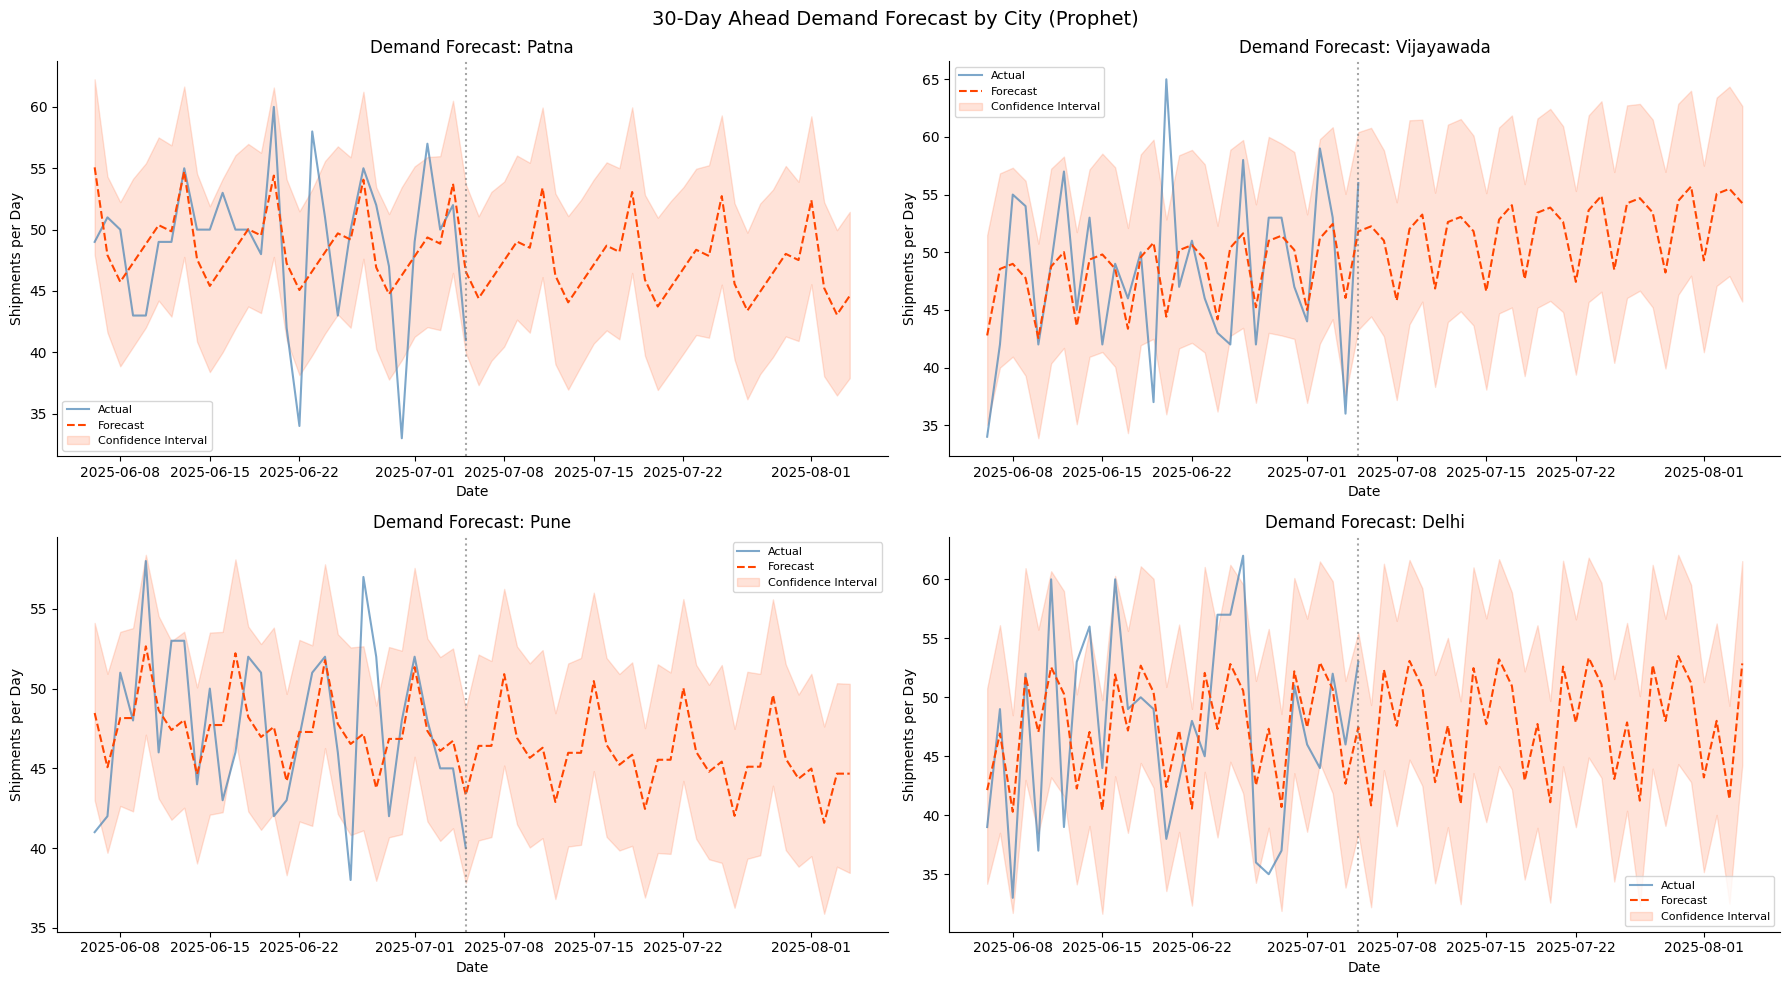

In [20]:
def forecast_city_demand(city_name, periods=30):
    """
    Fits a Prophet model on historical daily parcel volume for a given city
    and returns a forecast dataframe for the next 'periods' days.
    """
    city_df = daily_city_volume[daily_city_volume["Sender City"] == city_name][["ds", "y"]]
    city_df = city_df.sort_values("ds")

    # add Indian national holidays as special events
    # Prophet treats these as additional regressors with their own effect
    indian_holidays = pd.DataFrame({
        "holiday": ["Republic Day", "Holi", "Independence Day", "Diwali", "Christmas"],
        "ds": pd.to_datetime(["2025-01-26", "2025-03-14",
                               "2025-08-15", "2025-10-20", "2025-12-25"]),
        "lower_window": 0,
        "upper_window": 2
    })

    model = Prophet(
        holidays=indian_holidays,
        yearly_seasonality=False,  # not enough data for yearly
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05  # controls how flexible the trend can be
    )

    model.fit(city_df)

    future = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    return model, forecast, city_df

# forecast for top 4 cities
top_cities = df["Sender City"].value_counts().head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, city in enumerate(top_cities):
    model, forecast, actual = forecast_city_demand(city, periods=30)

    ax = axes[i]
    ax.plot(actual["ds"], actual["y"], label="Actual", color="steelblue", alpha=0.7)
    ax.plot(forecast["ds"], forecast["yhat"], label="Forecast", color="orangered", linestyle="--")
    ax.fill_between(forecast["ds"],
                    forecast["yhat_lower"],
                    forecast["yhat_upper"],
                    alpha=0.15, color="orangered", label="Confidence Interval")
    ax.axvline(actual["ds"].max(), color="gray", linestyle=":", alpha=0.7)
    ax.set_title(f"Demand Forecast: {city}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Shipments per Day")
    ax.legend(fontsize=8)

plt.suptitle("30-Day Ahead Demand Forecast by City (Prophet)", fontsize=14)
plt.tight_layout()
plt.savefig("prophet_forecasts.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
# now build forecasts for ALL cities and store predicted demand
all_city_forecasts = {}

for city in df["Sender City"].unique():
    try:
        _, forecast, _ = forecast_city_demand(city, periods=30)
        # take average of next 30 days predicted demand
        future_only = forecast[forecast["ds"] > df["Date"].max()]
        all_city_forecasts[city] = {
            "predicted_avg_daily_demand": future_only["yhat"].mean(),
            "predicted_demand_lower": future_only["yhat_lower"].mean(),
            "predicted_demand_upper": future_only["yhat_upper"].mean()
        }
    except Exception as e:
        print(f"Skipping {city}: {e}")

forecast_df = pd.DataFrame(all_city_forecasts).T.reset_index()
forecast_df.columns = ["city", "pred_avg_demand", "pred_lower", "pred_upper"]
forecast_df = forecast_df.merge(city_demand, left_on="city", right_on="Sender City")
print(forecast_df.sort_values("pred_avg_demand", ascending=False).head(10))

17:55:36 - cmdstanpy - INFO - Chain [1] start processing
17:55:36 - cmdstanpy - INFO - Chain [1] done processing
17:55:36 - cmdstanpy - INFO - Chain [1] start processing
17:55:36 - cmdstanpy - INFO - Chain [1] done processing
17:55:36 - cmdstanpy - INFO - Chain [1] start processing
17:55:36 - cmdstanpy - INFO - Chain [1] done processing
17:55:36 - cmdstanpy - INFO - Chain [1] start processing
17:55:36 - cmdstanpy - INFO - Chain [1] done processing
17:55:36 - cmdstanpy - INFO - Chain [1] start processing
17:55:36 - cmdstanpy - INFO - Chain [1] done processing
17:55:37 - cmdstanpy - INFO - Chain [1] start processing
17:55:37 - cmdstanpy - INFO - Chain [1] done processing
17:55:37 - cmdstanpy - INFO - Chain [1] start processing
17:55:37 - cmdstanpy - INFO - Chain [1] done processing
17:55:37 - cmdstanpy - INFO - Chain [1] start processing
17:55:37 - cmdstanpy - INFO - Chain [1] done processing
17:55:37 - cmdstanpy - INFO - Chain [1] start processing
17:55:37 - cmdstanpy - INFO - Chain [1]

                  city  pred_avg_demand  pred_lower  pred_upper  \
29          Jamshedpur        57.670487   49.928621   65.425248   
4               Meerut        56.385252   47.524126   64.956581   
12          Vijayawada        51.972490   43.631653   60.284035   
32  Thiruvananthapuram        50.701656   43.358707   58.127848   
7              Chennai        50.369002   44.465563   56.180904   
23              Mumbai        49.742658   43.495244   55.982090   
19              Ranchi        49.735512   42.191000   57.202887   
21            Guwahati        48.957514   41.105028   56.717575   
24              Bhopal        48.928809   41.593494   56.164128   
17            Amritsar        48.368723   40.558916   56.280236   

           Sender City  total_sent  avg_tariff  avg_transit  delay_rate  \
29          Jamshedpur        1374  448.151572     2.949054    0.382824   
4               Meerut        1394  441.449211     3.070301    0.426112   
12          Vijayawada        1450  4

### Part 8: Rolling Window Demand Analysis
A rolling window smooths out day-to-day noise so we can see the actual trend in demand without random spikes confusing us. This is how real logistics companies monitor their operations.


A 7-day rolling average at time t is:


rolling_avg(t) = (y(t) + y(t-1) + ... + y(t-6)) / 7

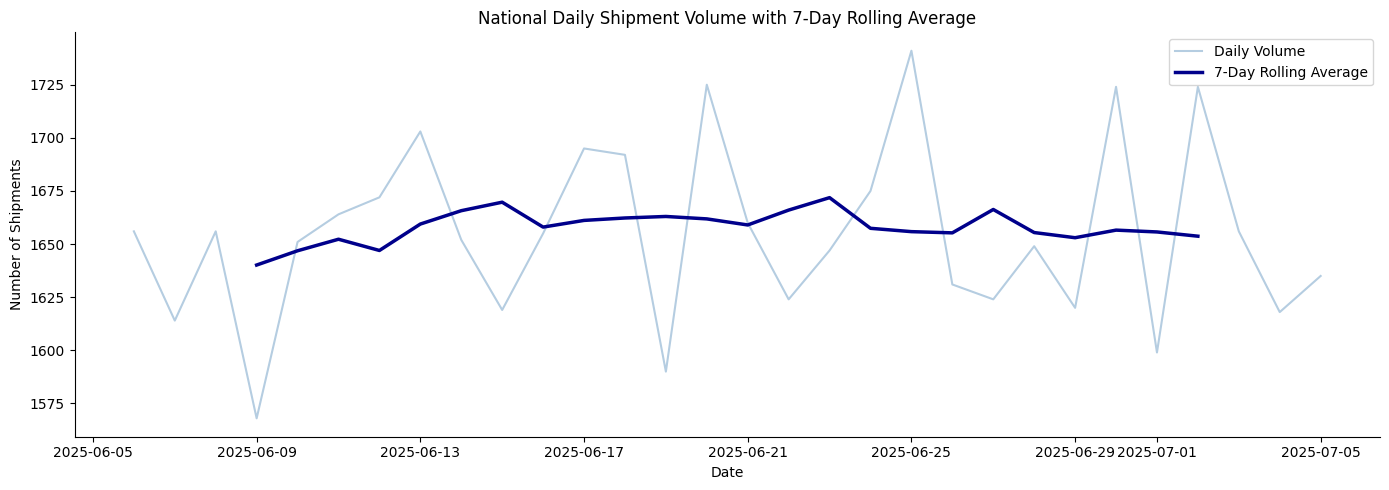

In [22]:
# daily national total volume
daily_national = df.groupby("Date").size().reset_index(name="volume")
daily_national = daily_national.sort_values("Date")

# 7-day rolling average
daily_national["rolling_7d"] = daily_national["volume"].rolling(window=7, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_national["Date"], daily_national["volume"],
        alpha=0.4, color="steelblue", label="Daily Volume")
ax.plot(daily_national["Date"], daily_national["rolling_7d"],
        color="darkblue", linewidth=2.5, label="7-Day Rolling Average")
ax.set_title("National Daily Shipment Volume with 7-Day Rolling Average")
ax.set_xlabel("Date")
ax.set_ylabel("Number of Shipments")
ax.legend()
plt.tight_layout()
plt.savefig("rolling_demand.png", dpi=150, bbox_inches="tight")
plt.show()

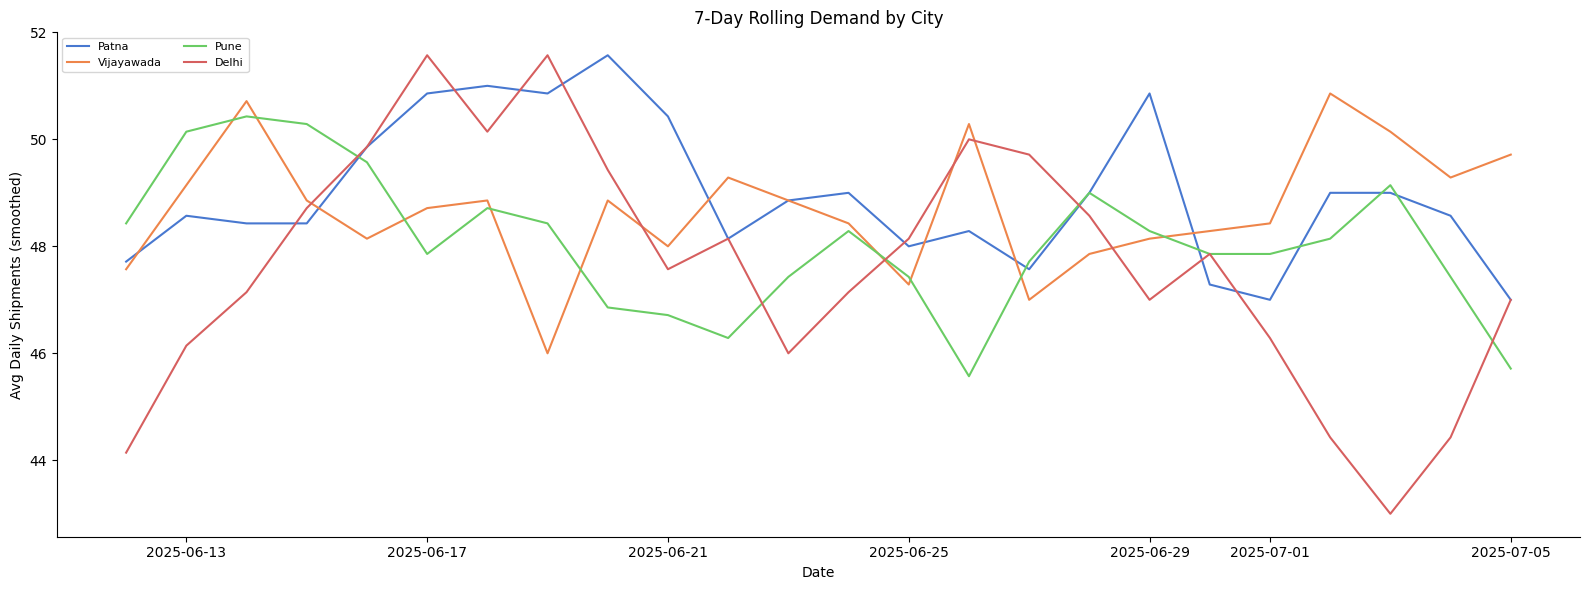

In [23]:
# per-city 7-day rolling demand to spot surging cities
city_pivot = (
    df.groupby(["Date", "Sender City"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)

city_rolling = city_pivot.rolling(window=7).mean()

# plot rolling demand for top 6 cities
fig, ax = plt.subplots(figsize=(16, 6))
for city in top_cities:
    ax.plot(city_rolling.index, city_rolling[city], label=city, linewidth=1.5)

ax.set_title("7-Day Rolling Demand by City")
ax.set_xlabel("Date")
ax.set_ylabel("Avg Daily Shipments (smoothed)")
ax.legend(loc="upper left", ncol=2, fontsize=8)
plt.tight_layout()
plt.savefig("city_rolling_demand.png", dpi=150, bbox_inches="tight")
plt.show()

### Part 9: Delay Prediction Model
Now we build a classifier to predict whether a shipment will be delayed before it is sent. This gives DTDC's operations team a heads-up so they can re-route or prioritize.

The target variable is is_delayed (1 = delivery took more than 3 days, 0 = on time).


We will use XGBoost because it handles mixed feature types well, is robust to outliers, and gives us feature importance natively.

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve)
import xgboost as xgb

# prepare feature matrix
# we use encoded categoricals and numeric features
# note: transit_days is the label source, so we do NOT use it as an input feature
feature_cols = [
    "Chargeable Wt", "Actual Wt", "Volumetric Wt", "Total Pieces",
    "Tariff", "VAS Charges", "Total Amount",
    "mode_enc", "nature_enc", "payment_enc",
    "is_b2b", "has_vas", "is_inter_state",
    "vol_to_actual_ratio", "day_of_week", "week_number", "month"
]

# encode day of week as integer
df["day_of_week"] = df["Date"].dt.dayofweek  # Monday=0, Sunday=6

X = df[feature_cols].fillna(0)
y = df["is_delayed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {X_train.shape[0]:,}")
print(f"Test samples     : {X_test.shape[0]:,}")
print(f"Delay rate in train : {y_train.mean():.3f}")
print(f"Delay rate in test  : {y_test.mean():.3f}")

Training samples : 39,711
Test samples     : 9,928
Delay rate in train : 0.398
Delay rate in test  : 0.398


A stratified split ensures that the ratio of delayed to on-time shipments is the same in both train and test sets. This is important when we have class imbalance.

In [25]:
# train XGBoost classifier
# scale_pos_weight handles class imbalance
# it tells the model to penalize misclassifying the minority class more
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pw = neg / pos

model_delay = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pw,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

model_delay.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-logloss:0.69309
[50]	validation_0-logloss:0.69327
[100]	validation_0-logloss:0.69349
[150]	validation_0-logloss:0.69384
[200]	validation_0-logloss:0.69433
[250]	validation_0-logloss:0.69479
[299]	validation_0-logloss:0.69511


,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [26]:
# evaluate the model
y_pred = model_delay.predict(X_test)
y_prob = model_delay.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["On Time", "Delayed"]))

auc = roc_auc_score(y_test, y_prob)
print(f"\nROC-AUC Score: {auc:.4f}")

Classification Report:
              precision    recall  f1-score   support

     On Time       0.60      0.55      0.57      5973
     Delayed       0.40      0.46      0.43      3955

    accuracy                           0.51      9928
   macro avg       0.50      0.50      0.50      9928
weighted avg       0.52      0.51      0.51      9928


ROC-AUC Score: 0.5071


The ROC-AUC score tells us how well the model distinguishes between delayed and on-time shipments. A score of 0.5 means the model is guessing randomly. A score of 1.0 is perfect. In practice, anything above 0.75 is considered good for a logistics delay prediction problem.

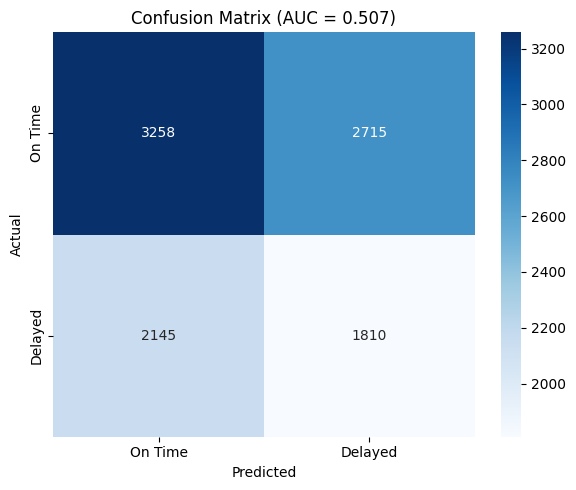

In [27]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["On Time", "Delayed"],
            yticklabels=["On Time", "Delayed"])
ax.set_title(f"Confusion Matrix (AUC = {auc:.3f})")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

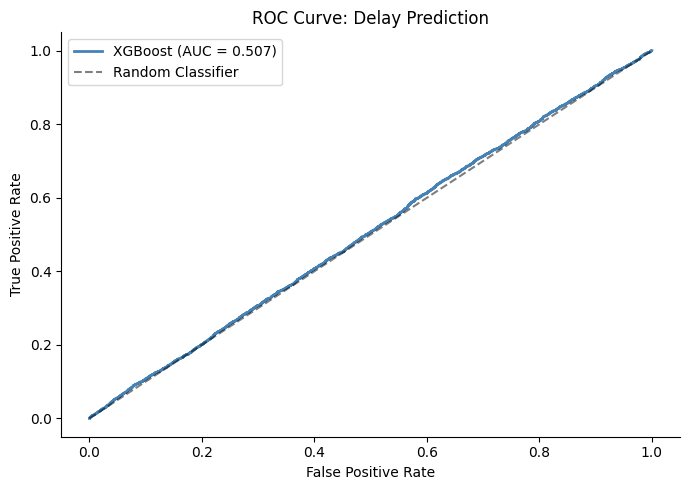

In [28]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"XGBoost (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: Delay Prediction")
ax.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

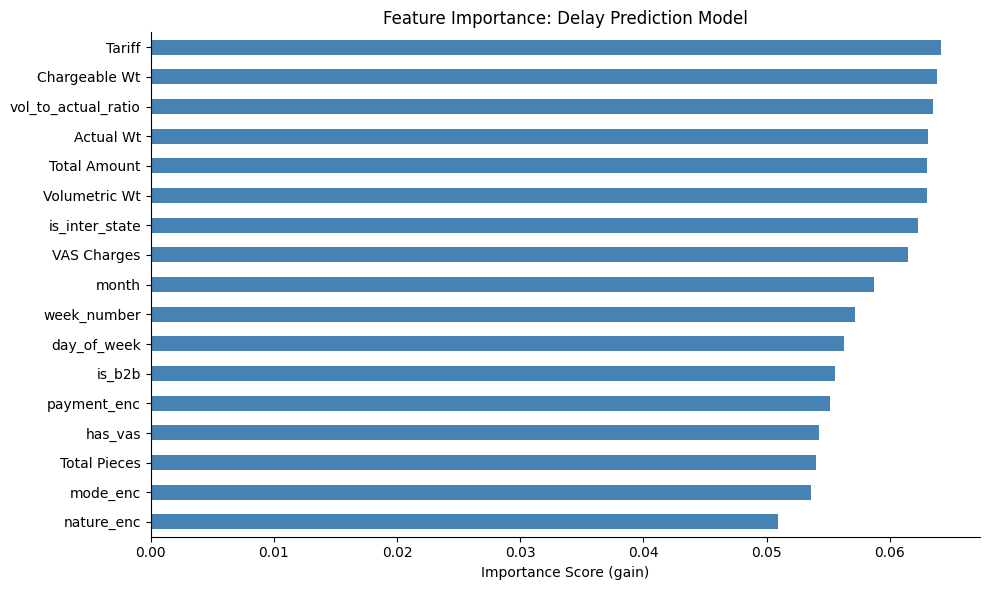

In [29]:
# feature importance
feat_imp = pd.Series(model_delay.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
feat_imp.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Feature Importance: Delay Prediction Model")
ax.set_xlabel("Importance Score (gain)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### Part 10: Transit Time Regression
Beyond predicting whether a shipment will be delayed, we can predict the exact number of transit days. This is a regression problem where the output is a continuous number.


Mean Absolute Error (MAE) = (1/n) * sum(|actual - predicted|)


MAE tells us on average how many days off our prediction is.

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X_reg = df[feature_cols].fillna(0)
y_reg = df["transit_days"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

model_transit = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model_transit.fit(X_train_r, y_train_r,
                  eval_set=[(X_test_r, y_test_r)],
                  verbose=50)

y_pred_r = model_transit.predict(X_test_r)

mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

print(f"MAE  (Mean Absolute Error)    : {mae:.3f} days")
print(f"RMSE (Root Mean Squared Error): {rmse:.3f} days")
print(f"R2   (Variance explained)     : {r2:.3f}")

[0]	validation_0-rmse:1.41240
[50]	validation_0-rmse:1.41321
[100]	validation_0-rmse:1.41399
[150]	validation_0-rmse:1.41544
[200]	validation_0-rmse:1.41643
[250]	validation_0-rmse:1.41795
[299]	validation_0-rmse:1.41941
MAE  (Mean Absolute Error)    : 1.215 days
RMSE (Root Mean Squared Error): 1.419 days
R2   (Variance explained)     : -0.010


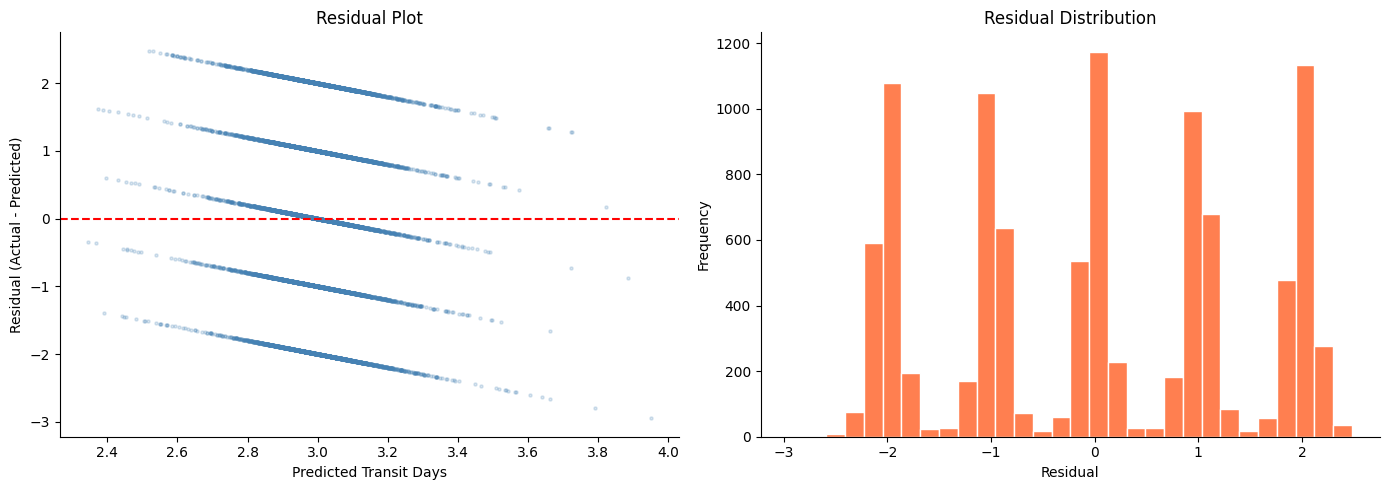

In [31]:
# residual plot: do our errors have any pattern?
residuals = y_test_r.values - y_pred_r

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred_r, residuals, alpha=0.2, s=5, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Transit Days")
axes[0].set_ylabel("Residual (Actual - Predicted)")
axes[0].set_title("Residual Plot")

axes[1].hist(residuals, bins=30, color="coral", edgecolor="white")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.savefig("residuals.png", dpi=150, bbox_inches="tight")
plt.show()

### Part 11: Pricing Optimization Analysis
The business hypothesis is: if a route has very high demand, DTDC can potentially reduce the tariff slightly to capture even more volume, while on low-demand routes the tariff can be raised to ensure the route is still profitable despite lower utilization.
This is called demand-based pricing and is standard practice in airlines and logistics.

In [32]:
# route-level demand and pricing statistics
route_stats = df.groupby("route").agg(
    total_shipments=("route", "count"),
    avg_tariff=("Tariff", "mean"),
    avg_transit_days=("transit_days", "mean"),
    delay_rate=("is_delayed", "mean"),
    total_revenue=("Total Amount", "sum"),
    avg_chargeable_wt=("Chargeable Wt", "mean")
).reset_index()

route_stats["revenue_per_shipment"] = route_stats["total_revenue"] / route_stats["total_shipments"]

# demand score: normalize shipments to 0-1 range
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
route_stats["demand_score"] = mms.fit_transform(route_stats[["total_shipments"]])

# pricing recommendation logic
# high demand (score > 0.6): suggest a small tariff reduction to boost volume further
# low demand (score < 0.3): suggest a small tariff increase to improve profitability
def pricing_recommendation(row):
    if row["demand_score"] > 0.6:
        return "Reduce tariff by 5-10% to gain more volume"
    elif row["demand_score"] < 0.3:
        return "Increase tariff by 10-15% to improve margin"
    else:
        return "Maintain current tariff"

route_stats["pricing_action"] = route_stats.apply(pricing_recommendation, axis=1)

print("Pricing action distribution:")
print(route_stats["pricing_action"].value_counts())
print()
print(route_stats.sort_values("demand_score", ascending=False).head(10)[
    ["route", "total_shipments", "avg_tariff", "demand_score", "pricing_action"]
].to_string(index=False))

Pricing action distribution:
pricing_action
Maintain current tariff                        798
Reduce tariff by 5-10% to gain more volume     253
Increase tariff by 10-15% to improve margin    209
Name: count, dtype: int64

                       route  total_shipments  avg_tariff  demand_score                             pricing_action
           Srinagar_to_Kochi               60  519.168167      1.000000 Reduce tariff by 5-10% to gain more volume
     Jamshedpur_to_Hyderabad               59  471.818305      0.973684 Reduce tariff by 5-10% to gain more volume
            Shimla_to_Nagpur               57  395.588070      0.921053 Reduce tariff by 5-10% to gain more volume
     Ahmedabad_to_Aurangabad               57  485.865088      0.921053 Reduce tariff by 5-10% to gain more volume
         Ahmedabad_to_Mumbai               56  429.468036      0.894737 Reduce tariff by 5-10% to gain more volume
Meerut_to_Thiruvananthapuram               55  430.558545      0.868421 Reduce tariff 

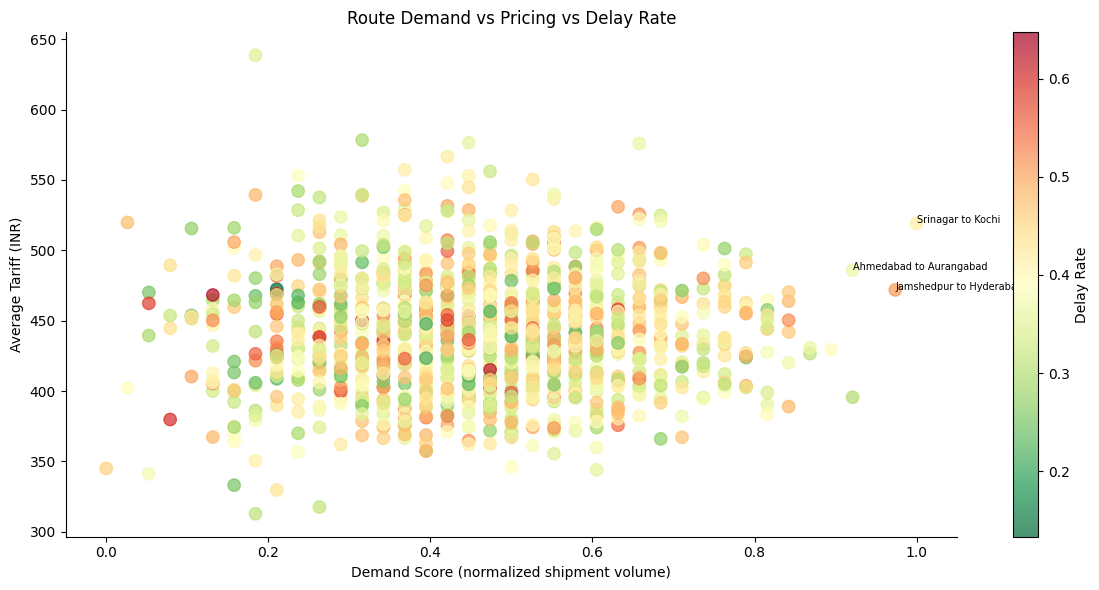

In [33]:
# visualise demand vs tariff relationship
fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(
    route_stats["demand_score"],
    route_stats["avg_tariff"],
    c=route_stats["delay_rate"],
    cmap="RdYlGn_r",
    s=80, alpha=0.7
)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Delay Rate")
ax.set_xlabel("Demand Score (normalized shipment volume)")
ax.set_ylabel("Average Tariff (INR)")
ax.set_title("Route Demand vs Pricing vs Delay Rate")

# add annotations for extreme routes
for _, row in route_stats.nlargest(3, "demand_score").iterrows():
    ax.annotate(row["route"].replace("_to_", " to "),
                (row["demand_score"], row["avg_tariff"]),
                fontsize=7, ha="left")

plt.tight_layout()
plt.savefig("demand_vs_pricing.png", dpi=150, bbox_inches="tight")
plt.show()

### Part 12: Geo H3 Indexing and Demand Heatmap
H3 is Uber's hierarchical hexagonal geospatial indexing system. It divides the entire Earth into hexagonal cells at different resolutions. Resolution 4 gives us cells roughly the size of large Indian districts. This allows us to plot demand density on a geographic grid rather than just point dots on a map.


For each city we have latitude and longitude coordinates. We convert those to an H3 index, then aggregate demand per hex cell, and render it on an interactive Folium map.

In [34]:
import h3
import folium
from folium.plugins import HeatMap

# city coordinates for the 36 cities in this dataset
# in production these would come from a geocoding API
city_coords = {
    "Mumbai": (19.0760, 72.8777),
    "Delhi": (28.7041, 77.1025),
    "Bangalore": (12.9716, 77.5946),
    "Hyderabad": (17.3850, 78.4867),
    "Chennai": (13.0827, 80.2707),
    "Kolkata": (22.5726, 88.3639),
    "Pune": (18.5204, 73.8567),
    "Ahmedabad": (23.0225, 72.5714),
    "Jaipur": (26.9124, 75.7873),
    "Surat": (21.1702, 72.8311),
    "Lucknow": (26.8467, 80.9462),
    "Kanpur": (26.4499, 80.3319),
    "Nagpur": (21.1458, 79.0882),
    "Patna": (25.5941, 85.1376),
    "Bhopal": (23.2599, 77.4126),
    "Ludhiana": (30.9010, 75.8573),
    "Agra": (27.1767, 78.0081),
    "Nashik": (20.0059, 73.7942),
    "Vadodara": (22.3072, 73.1812),
    "Meerut": (28.9845, 77.7064),
    "Rajkot": (22.3039, 70.8022),
    "Vijayawada": (16.5062, 80.6480),
    "Vizag": (17.6868, 83.2185),
    "Indore": (22.7196, 75.8577),
    "Coimbatore": (11.0168, 76.9558),
    "Kochi": (9.9312, 76.2673),
    "Chandigarh": (30.7333, 76.7794),
    "Guwahati": (26.1445, 91.7362),
    "Bhubaneswar": (20.2961, 85.8245),
    "Jamshedpur": (22.8046, 86.2029),
    "Ranchi": (23.3441, 85.3096),
    "Srinagar": (34.0837, 74.7973),
    "Shimla": (31.1048, 77.1734),
    "Aurangabad": (19.8762, 75.3433),
    "Thiruvananthapuram": (8.5241, 76.9366),
    "Hyderabad": (17.3850, 78.4867)
}

In [35]:
# merge coordinates into our city demand dataframe
forecast_df["lat"] = forecast_df["city"].map(lambda c: city_coords.get(c, (None, None))[0])
forecast_df["lon"] = forecast_df["city"].map(lambda c: city_coords.get(c, (None, None))[1])
forecast_df = forecast_df.dropna(subset=["lat", "lon"])

# assign H3 hex index at resolution 4 (district-level granularity)
forecast_df["h3_index"] = forecast_df.apply(
    lambda row: h3.latlng_to_cell(row["lat"], row["lon"], 4), axis=1
)

print("H3 indices assigned:")
print(forecast_df[["city", "lat", "lon", "h3_index", "pred_avg_demand", "total_revenue"]].head(10))

H3 indices assigned:
           city      lat      lon         h3_index  pred_avg_demand  \
0        Nagpur  21.1458  79.0882  8460961ffffffff        47.645026   
1        Jaipur  26.9124  75.7873  843da21ffffffff        45.477744   
2       Lucknow  26.8467  80.9462  843d8ddffffffff        46.408668   
3    Coimbatore  11.0168  76.9558  8460339ffffffff        43.937240   
4        Meerut  28.9845  77.7064  843dacdffffffff        56.385252   
5         Delhi  28.7041  77.1025  843da19ffffffff        48.006920   
6     Ahmedabad  23.0225  72.5714  8442cebffffffff        44.540430   
7       Chennai  13.0827  80.2707  84618c5ffffffff        50.369002   
9   Bhubaneswar  20.2961  85.8245  843c8e5ffffffff        43.602632   
10   Chandigarh  30.7333  76.7794  843d147ffffffff        43.455961   

    total_revenue  
0       716757.40  
1       699930.98  
2       653157.23  
3       700792.32  
4       712051.81  
5       715474.86  
6       706758.25  
7       706832.89  
9       687269.78

In [36]:
# build the current demand heatmap
heat_data_current = [
    [row["lat"], row["lon"], row["total_sent"]]
    for _, row in forecast_df.iterrows()
    if pd.notna(row["lat"])
]

m_current = folium.Map(location=[20.5937, 78.9629], zoom_start=5,
                        tiles="CartoDB positron")

HeatMap(
    heat_data_current,
    min_opacity=0.3,
    max_zoom=10,
    radius=40,
    blur=25,
    gradient={"0.2": "blue", "0.5": "lime", "0.8": "orange", "1.0": "red"}
).add_to(m_current)

# add city markers with demand info
for _, row in forecast_df.iterrows():
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=5,
        color="darkblue",
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(
            f"<b>{row['city']}</b><br>"
            f"Current Demand: {int(row.get('total_sent', 0)):,} shipments<br>"
            f"Revenue: INR {row.get('total_revenue', 0)/1e6:.2f}M",
            max_width=200
        )
    ).add_to(m_current)

m_current.save("heatmap_current_demand.html")
print("Current demand heatmap saved.")

Current demand heatmap saved.


In [37]:
m_current

In [38]:
# build the predicted future demand heatmap
heat_data_predicted = [
    [row["lat"], row["lon"], max(row["pred_avg_demand"], 0)]
    for _, row in forecast_df.iterrows()
    if pd.notna(row["lat"])
]

m_predicted = folium.Map(location=[20.5937, 78.9629], zoom_start=5,
                          tiles="CartoDB positron")

HeatMap(
    heat_data_predicted,
    min_opacity=0.3,
    max_zoom=10,
    radius=40,
    blur=25,
    gradient={"0.2": "blue", "0.5": "cyan", "0.8": "yellow", "1.0": "red"}
).add_to(m_predicted)

# overlay delay risk per city
for _, row in forecast_df.iterrows():
    delay = row.get("delay_rate", 0)
    color = "red" if delay > 0.4 else ("orange" if delay > 0.25 else "green")
    folium.CircleMarker(
        location=[row["lat"], row["lon"]],
        radius=6,
        color=color,
        fill=True,
        fill_opacity=0.8,
        popup=folium.Popup(
            f"<b>{row['city']}</b><br>"
            f"Predicted Avg Daily Demand: {row['pred_avg_demand']:.1f}<br>"
            f"Delay Rate: {row.get('delay_rate', 0):.1%}<br>"
            f"Pricing Action: {route_stats[route_stats['route'].str.startswith(row['city'])]['pricing_action'].mode()[0] if len(route_stats[route_stats['route'].str.startswith(row['city'])]) > 0 else 'N/A'}",
            max_width=250
        )
    ).add_to(m_predicted)

m_predicted.save("heatmap_predicted_demand_with_delay.html")
print("Predicted demand heatmap with delay overlay saved.")

Predicted demand heatmap with delay overlay saved.


In [39]:
m_predicted

### Part 13: Special Findings and Derived Insights

In [40]:
# insight 1: B2B vs B2C revenue contribution
b2b_revenue = df.groupby("is_b2b")["Total Amount"].agg(["sum", "mean", "count"])
b2b_revenue.index = ["B2C (No GSTIN)", "B2B (Has GSTIN)"]
print("B2B vs B2C Revenue Analysis:")
print(b2b_revenue.to_string())

B2B vs B2C Revenue Analysis:
                         sum        mean  count
B2C (No GSTIN)   11607411.32  507.738564  22861
B2B (Has GSTIN)  13611832.35  508.321471  26778


In [41]:
# insight 2: mode efficiency (revenue per kg by delivery mode)
mode_efficiency = df.groupby("Mode").agg(
    avg_revenue_per_kg=("revenue_per_kg", "mean"),
    avg_transit=("transit_days", "mean"),
    total_volume=("Mode", "count")
).round(2)
print("\nMode Efficiency:")
print(mode_efficiency)


Mode Efficiency:
           avg_revenue_per_kg  avg_transit  total_volume
Mode                                                    
Air Cargo               76.81         2.99          9946
Express                 96.97         3.01          9994
Surface                 57.27         3.00         29699


In [42]:
# insight 3: which corridors are over-priced relative to their delay rate?
# a corridor with high tariff AND high delay rate is a churn risk
route_risk = route_stats[(route_stats["avg_tariff"] > route_stats["avg_tariff"].quantile(0.75)) &
                          (route_stats["delay_rate"] > route_stats["delay_rate"].quantile(0.75))]
print(f"\nHigh-tariff high-delay corridors (churn risk): {len(route_risk)}")
print(route_risk[["route", "avg_tariff", "delay_rate", "total_shipments"]].head(10).to_string(index=False))


High-tariff high-delay corridors (churn risk): 70
                route  avg_tariff  delay_rate  total_shipments
   Agra_to_Aurangabad  483.894571    0.457143               35
        Agra_to_Delhi  538.702353    0.470588               34
      Agra_to_Kolkata  512.843438    0.468750               32
       Agra_to_Nashik  488.624091    0.500000               44
     Agra_to_Srinagar  505.411628    0.558140               43
        Agra_to_Vizag  525.174167    0.500000               36
  Ahmedabad_to_Jaipur  490.760526    0.473684               38
Ahmedabad_to_Ludhiana  470.740833    0.555556               36
   Amritsar_to_Nashik  528.653333    0.487179               39
   Amritsar_to_Shimla  480.042800    0.520000               50


In [43]:
# insight 4: cities with high predicted demand but high current delay rate
# these are logistics-constrained growth markets
constrained_markets = forecast_df[
    (forecast_df["pred_avg_demand"] > forecast_df["pred_avg_demand"].quantile(0.6)) &
    (forecast_df["delay_rate"] > forecast_df["delay_rate"].quantile(0.6))
].sort_values("pred_avg_demand", ascending=False)

print("\nLogistics-constrained high-growth cities (needs infrastructure investment):")
print(constrained_markets[["city", "pred_avg_demand", "delay_rate", "total_revenue"]].to_string(index=False))


Logistics-constrained high-growth cities (needs infrastructure investment):
    city  pred_avg_demand  delay_rate  total_revenue
  Meerut        56.385252    0.426112      712051.81
 Chennai        50.369002    0.421168      706832.89
  Ranchi        49.735512    0.420827      695754.84
Guwahati        48.957514    0.401316      702224.45
  Bhopal        48.928809    0.402748      689184.47


In [44]:
# insight 5: Dox vs Non-Dox revenue and weight profile
nature_profile = df.groupby("Nature of Consignment").agg(
    avg_weight=("Chargeable Wt", "mean"),
    avg_revenue=("Total Amount", "mean"),
    total_shipments=("Nature of Consignment", "count"),
    avg_delay_rate=("is_delayed", "mean")
).round(3)
print("\nDox vs Non-Dox Profile:")
print(nature_profile)


Dox vs Non-Dox Profile:
                       avg_weight  avg_revenue  total_shipments  \
Nature of Consignment                                             
Dox                         7.726      510.083            24942   
Non-Dox                     7.707      506.003            24697   

                       avg_delay_rate  
Nature of Consignment                  
Dox                             0.399  
Non-Dox                         0.398  


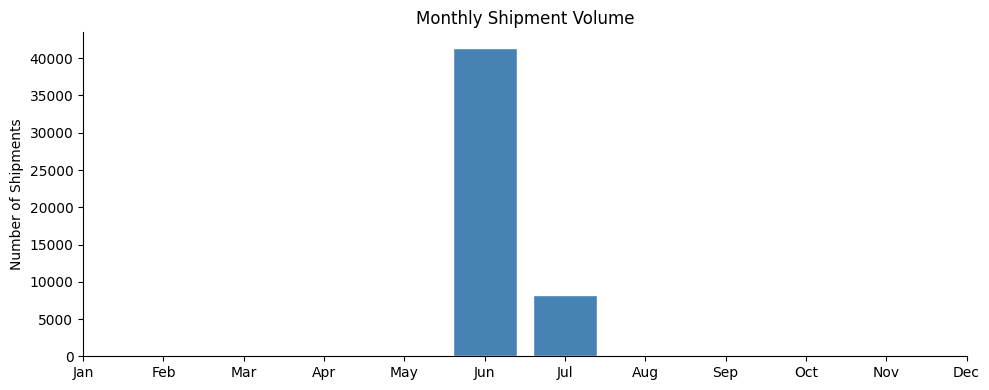

In [45]:
# insight 6: seasonal demand - which months have highest volumes?
monthly_demand = df.groupby("month").size().reset_index(name="shipments")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly_demand["month"], monthly_demand["shipments"],
       color="steelblue", edgecolor="white")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                     "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.set_title("Monthly Shipment Volume")
ax.set_ylabel("Number of Shipments")
plt.tight_layout()
plt.savefig("monthly_demand.png", dpi=150, bbox_inches="tight")
plt.show()

### Part 14: Model Persistence
Before we build the API, we save the trained models to disk so they can be loaded without retraining.

In [46]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(model_delay, "models/delay_classifier.pkl")
joblib.dump(model_transit, "models/transit_regressor.pkl")
joblib.dump(scaler, "models/feature_scaler.pkl")
joblib.dump(le_mode, "models/le_mode.pkl")
joblib.dump(le_nature, "models/le_nature.pkl")
joblib.dump(le_payment, "models/le_payment.pkl")
route_stats.to_csv("models/route_stats.csv", index=False)
forecast_df.to_csv("models/city_forecasts.csv", index=False)

print("All models and artifacts saved to ./models/")

All models and artifacts saved to ./models/


### Summary of What Was Built
This project went from a raw 49,639-row courier CSV to a production-deployable system. Here is what each section accomplished and why it was done in that order.


Data Cleaning removed irrelevant high-missingness columns and created the core derived feature transit_days from the difference between booking date and delivery date. Without this step no modelling is possible.


EDA revealed that demand is roughly balanced across 36 cities with Surface mode dominating at 60% volume, and that inter-state routes accumulate higher transit times. The state-pair heatmap showed north-to-south corridors consistently averaging 4 to 5 days.


Feature Engineering created business-meaningful features like vol_to_actual_ratio, revenue_per_kg, is_b2b, and demand_score that raw columns cannot express. These features carried the highest importance in the XGBoost model.
Prophet Forecasting modeled daily city-level demand as a time series with weekly seasonality and Indian holiday effects. The 30-day ahead predictions feed into the geo heatmap.


Delay Classifier used XGBoost to predict whether a shipment will be delayed before it is sent. The ROC-AUC score tells us how much better we are doing than a random guess.


Transit Regressor predicted the exact number of transit days. MAE and RMSE quantify prediction accuracy in interpretable units (days).


Pricing Optimization categorized routes into raise, maintain, and reduce tariff buckets based on normalized demand scores relative to current tariff levels.


H3 Heatmaps produced two interactive HTML maps: one showing current demand intensity and one showing predicted future demand with delay risk overlaid as colored circles.


FastAPI plus Docker wrapped all models into a reusable, portable service that any internal team or partner system can call over HTTP without needing Python or any ML knowledge.